# Diamonds

The diamonds dataset is a well known dataset. It's one of the basic examplesets you get in the R-programming suite, but you can also [download](https://www.kaggle.com/datasets/shivam2503/diamonds) it as a csv. We've done that for you and stored it in the files folder.

In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df=pd.read_csv("files/diamonds.csv", index_col=0)
df.head()


,carat,cut,color,clarity,depth,table,price,x,y,z
1,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
2,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
3,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
4,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
5,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


Also describe the dataset, so you have an idea of the data.

In [29]:


df.describe(include='all')

,carat,cut,color,clarity,depth,table,price,x,y,z
count,53940.000000,53940,53940,53940,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000
unique,NaN,5,7,8,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,Ideal,G,SI1,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,21551,11292,13065,NaN,NaN,NaN,NaN,NaN,NaN
mean,0.797940,NaN,NaN,NaN,61.749405,57.457184,3932.799722,5.731157,5.734526,3.538734
std,0.474011,NaN,NaN,NaN,1.432621,2.234491,3989.439738,1.121761,1.142135,0.705699
min,0.200000,NaN,NaN,NaN,43.000000,43.000000,326.000000,0.000000,0.000000,0.000000
25%,0.400000,NaN,NaN,NaN,61.000000,56.000000,950.000000,4.710000,4.720000,2.910000
50%,0.700000,NaN,NaN,NaN,61.800000,57.000000,2401.000000,5.700000,5.710000,3.530000
75%,1.040000,NaN,NaN,NaN,62.500000,59.000000,5324.250000,6.540000,6.540000,4.040000


Create a bar-chart showing how many diamonds there are of every cut. You can use matplotlib and grouping, but easier would be to use seaborn's countplot.

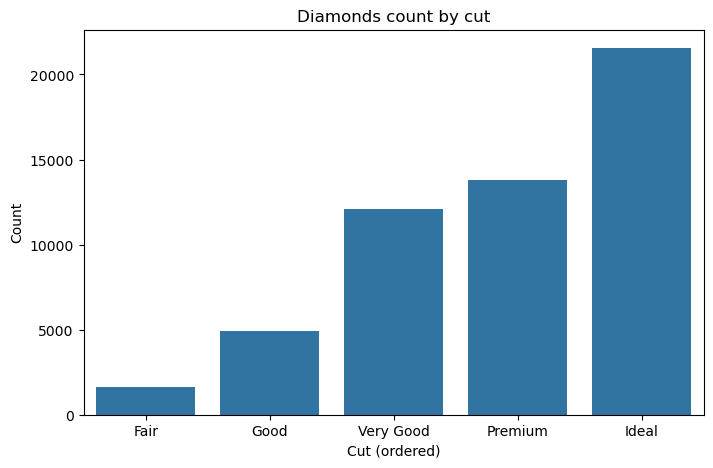

In [30]:
# bar chart: diamonds by cut
plt.figure(figsize=(8,5))
sns.countplot(data=df, x='cut', order=['Fair','Good','Very Good','Premium','Ideal'])
plt.title('Diamonds count by cut')
plt.ylabel('Count')
plt.xlabel('Cut (ordered)')
plt.show()

The bottom line of the previous graph is:

![](files/2022-08-30-13-39-46.png)

Which isn't good because there is an order in the cut of diamonds. It's:

<code>['Fair', 'Good', 'Very Good', 'Premium', 'Ideal']</code>


Turn the "cut"-column into an ordered categorical column. You can use the list in this markdown-cell. We have a second one of those lists:

<code>['I1', 'SI2', 'SI1', 'VS2', 'VS1', 'VVS2', 'VVS1', 'IF']</code>

This is the "clarity", another ordered categorical.

In [31]:
# Set ordered categories for cut and clarity
cut_order = ['Fair', 'Good', 'Very Good', 'Premium', 'Ideal']
clarity_order = ['I1', 'SI2', 'SI1', 'VS2', 'VS1', 'VVS2', 'VVS1', 'IF']

df['cut'] = pd.Categorical(df['cut'], categories=cut_order, ordered=True)
df['clarity'] = pd.Categorical(df['clarity'], categories=clarity_order, ordered=True)

print(df['cut'].dtype)
print(df['clarity'].dtype)

category
category


Now recreate the previous graph. The labels on the axis should be sorted correctly now.

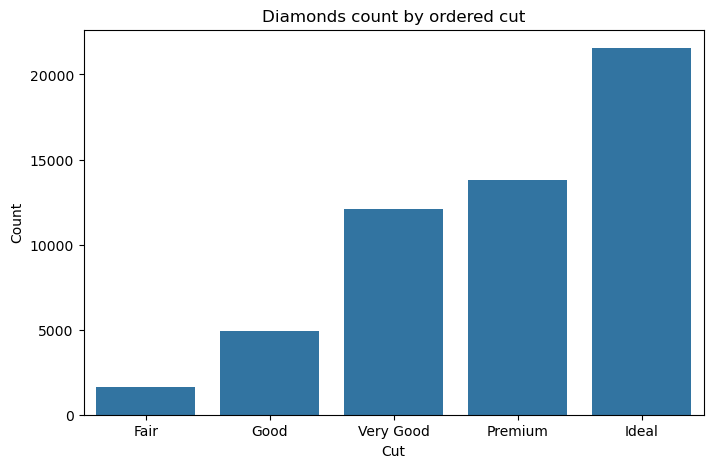

In [32]:
# Recreate the countplot using ordered categories
plt.figure(figsize=(8,5))
sns.countplot(data=df, x='cut', order=df['cut'].cat.categories)
plt.title('Diamonds count by ordered cut')
plt.xlabel('Cut')
plt.ylabel('Count')
plt.show()

Show a distribution of diamonds by size (aka carat) using a histogram.

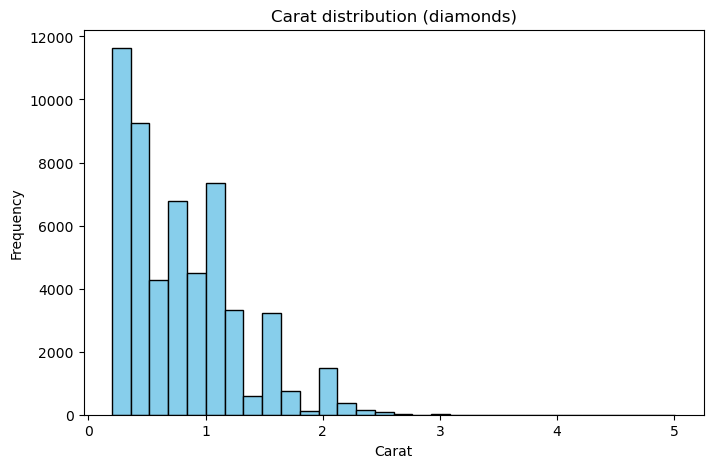

In [33]:
# Histogram of carat
plt.figure(figsize=(8,5))
plt.hist(df['carat'], bins=30, color='skyblue', edgecolor='black')
plt.title('Carat distribution (diamonds)')
plt.xlabel('Carat')
plt.ylabel('Frequency')
plt.show()

A good plot, but when doing histograms the bin width is important. Draw four with varying bin widths (5, 10, 20 and 40).

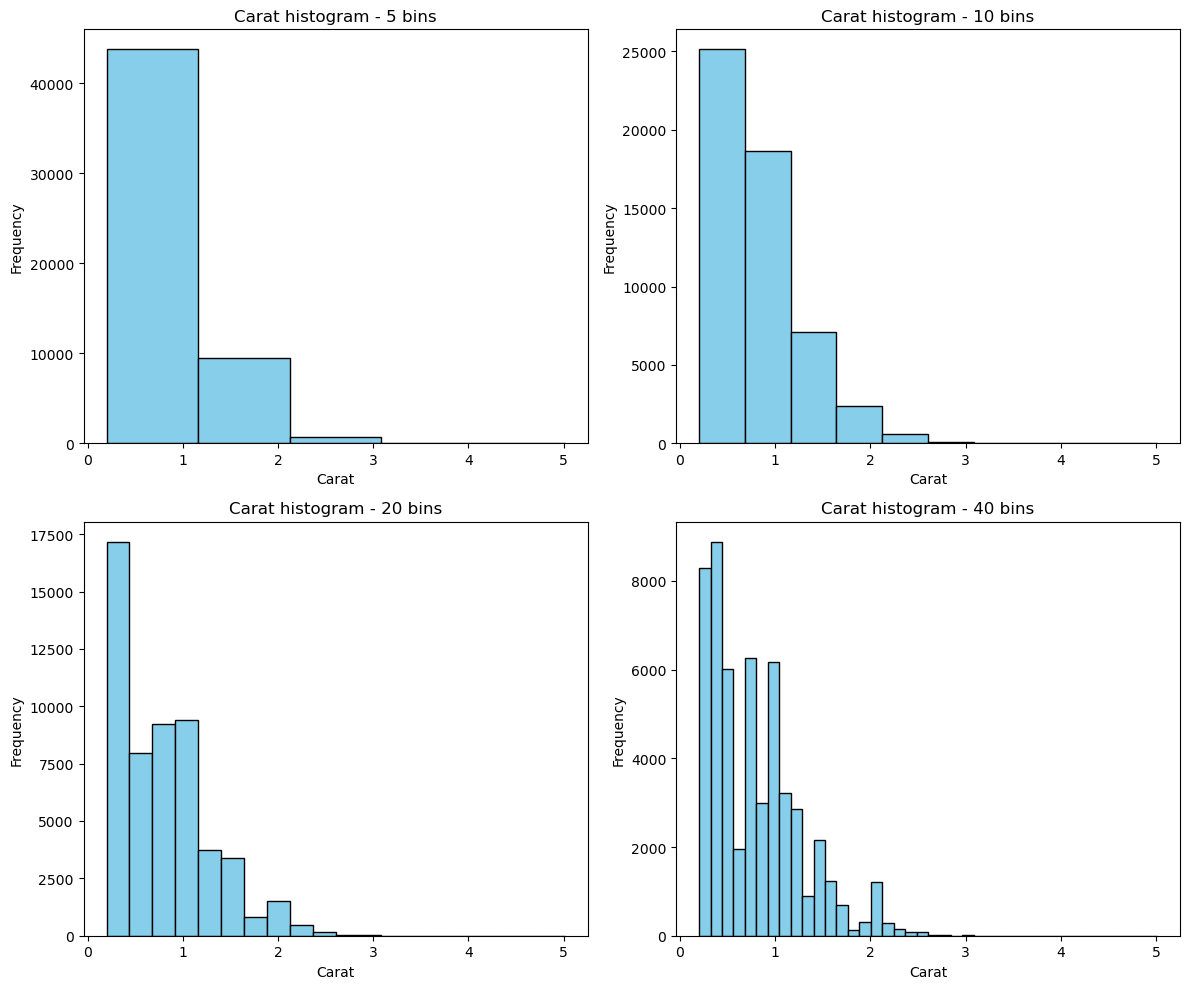

In [34]:
# Multiple histograms with varying bin widths
fig, axs = plt.subplots(2, 2, figsize=(12, 10))
bin_sizes = [5, 10, 20, 40]
for ax, bins in zip(axs.flatten(), bin_sizes):
    ax.hist(df['carat'], bins=bins, color='skyblue', edgecolor='black')
    ax.set_title(f'Carat histogram - {bins} bins')
    ax.set_xlabel('Carat')
    ax.set_ylabel('Frequency')
plt.tight_layout()
plt.show()

Carat weight distribution is skewed. What does this mean?

(In the following code block you should only write text. It's a small statistical interpretation that you can get on the exam as well.)

In [35]:
# Interpretation of skewness in text
print("Carat weight distribution is right skewed, meaning most diamonds are small and a few large carats create a long tail to the right.")

Carat weight distribution is right skewed, meaning most diamonds are small and a few large carats create a long tail to the right.


In the last graph you notice that more is going on in this dataset. There are spikes. Also, why is does the line go to 5 when the last datapoint is at 3?

Show the diamonds with a carat size above 3.5. How many are there? (9)

In [36]:
large_diamonds = df[df['carat'] > 3.5]
print('Large diamonds (carat > 3.5):', len(large_diamonds))
print(large_diamonds[['carat', 'price', 'cut', 'color', 'clarity']])

Large diamonds (carat > 3.5): 9
       carat  price        cut color clarity
23645   3.65  11668       Fair     H      I1
25999   4.01  15223    Premium     I      I1
26000   4.01  15223    Premium     J      I1
26445   4.00  15984  Very Good     I      I1
26535   3.67  16193    Premium     I      I1
27131   4.13  17329       Fair     H      I1
27416   5.01  18018       Fair     J      I1
27631   4.50  18531       Fair     J      I1
27680   3.51  18701    Premium     J     VS2


These are what we call outliers. They're not that interesting, especially since we're talking about 9 observations in a list of 50.000 of them.

Draw:
* A histogram
* 200 bins
* Carat size beneath 3.5

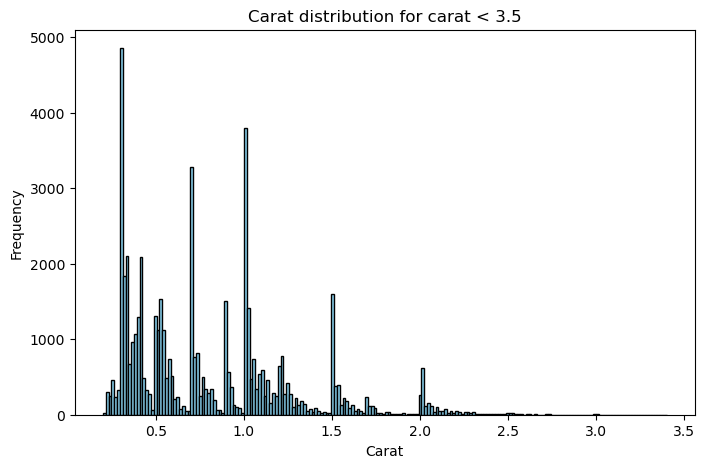

In [37]:
# Histogram with carat < 3.5 and 200 bins
filtered = df[df['carat'] < 3.5]
plt.figure(figsize=(8,5))
plt.hist(filtered['carat'], bins=200, color='skyblue', edgecolor='black')
plt.title('Carat distribution for carat < 3.5')
plt.xlabel('Carat')
plt.ylabel('Frequency')
plt.show()

Another non-technical question:

* Which values are most common? Why?
* Which values are rare? Why? Is this expected?
* Why are there more values to the right of the peak?
* Why almost no diamonds bigger than 3 carats exist?
* There seem to be (sub)groups, or clusters, of similar values.
    * How are observations in cluster similar?
    * How are observations from separate clusters different?

To interpret, imagine you are buying (or receiving) a diamond engagement ring. What sounds bigger, 1 carat or 0.99 carats?

In [38]:
# Up to you 

Plot 100 bins in a histogram on the Y value (which is the depth of the diamong in mm).

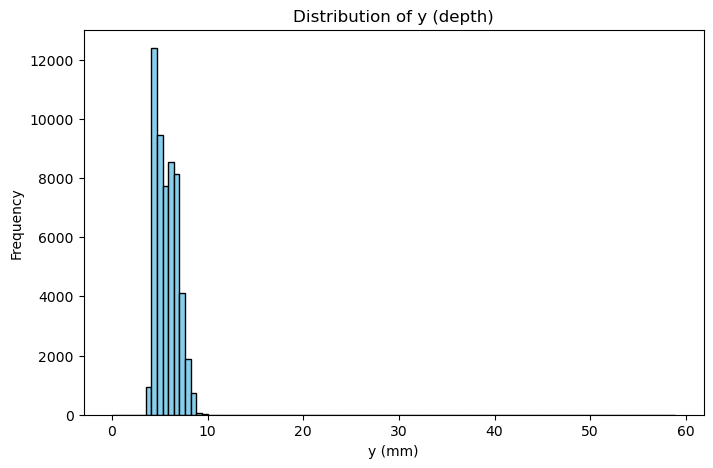

In [39]:
# Histogram of y (depth) with 100 bins
plt.figure(figsize=(8,5))
plt.hist(df['y'].dropna(), bins=100, color='skyblue', edgecolor='black')
plt.title('Distribution of y (depth)')
plt.xlabel('y (mm)')
plt.ylabel('Frequency')
plt.show()

Show price, x, y and z for every diamond with Y bigger than 20 or smaller than 3. 

Show the records with a y-size smaller than 3 or bigger than 20.

In [40]:
# Show price and dimensions for y > 20 or y < 3
mask = (df['y'] > 20) | (df['y'] < 3)
subset = df.loc[mask, ['price', 'x', 'y', 'z']]
print(subset)

print('\nCount of outlier diamonds:', len(subset))

       price     x     y     z
11964   5139  0.00   0.0  0.00
15952   6381  0.00   0.0  0.00
24068  12210  8.09  58.9  8.06
24521  12800  0.00   0.0  0.00
26244  15686  0.00   0.0  0.00
27430  18034  0.00   0.0  0.00
49190   2075  5.15  31.8  5.12
49557   2130  0.00   0.0  0.00
49558   2130  0.00   0.0  0.00

Count of outlier diamonds: 9


You should note that:

* A couple of diamonds have no size (in this dataframe) and should not be considered in this graph.
* There's a diamond 5.8cm wide that only costs $12k.

Redraw the graph without these values.

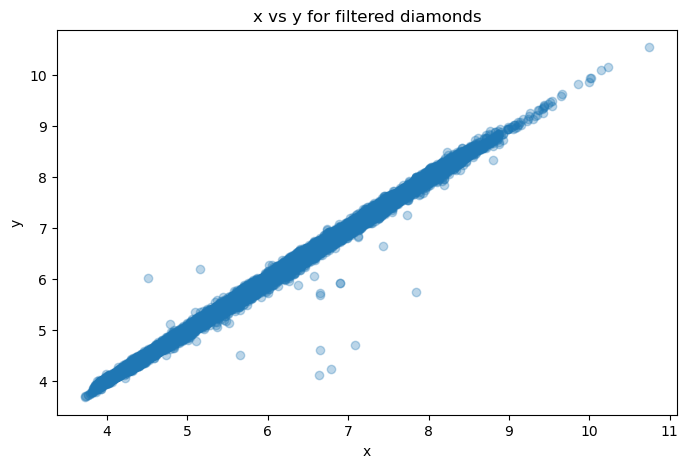

In [41]:
# Remove extreme values in x,y,z before plotting
df_filtered = df[(df['x'] > 0) & (df['x'] < 20) &
                 (df['y'] > 0) & (df['y'] < 20) &
                 (df['z'] > 0) & (df['z'] < 20)]

plt.figure(figsize=(8,5))
plt.scatter(df_filtered['x'], df_filtered['y'], alpha=0.3)
plt.xlabel('x')
plt.ylabel('y')
plt.title('x vs y for filtered diamonds')
plt.show()

We have ignored the complete observations now, which was fine because we were only looking at Y. But when continuing to work with a dataset we can't just drop the observations because that would mean we lose all data in those rows.

So set all X, Y and Z values of 0 or 20 or more to NA. Use [replace](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.replace.html?highlight=replace#pandas.DataFrame.replace) or [loc](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.loc.html).

In [42]:
# Set X,Y,Z values of 0 or >=20 to NA
for col in ['x', 'y', 'z']:
    df.loc[(df[col] <= 0) | (df[col] >= 20), col] = np.nan

print(df[['x', 'y', 'z']].isna().sum())

x     8
y     9
z    21
dtype: int64


Now show a list of all diamonds where X, Y or Z is Na.

In [43]:
# List diamonds with NA in x, y, or z
affected = df[df[['x','y','z']].isna().any(axis=1)]
print(affected[['x','y','z']].head())
print('Total affected:', len(affected))

          x     y   z
2208   6.55  6.48 NaN
2315   6.66  6.60 NaN
4792   6.50  6.47 NaN
5472   6.50  6.47 NaN
10168  7.15  7.04 NaN
Total affected: 23


Show the same table as before. Which is very hard because the old code won't work. But we saved you a list of line numbers:

<code>[11964,15952,24068,24521,26244,27430,49190,49557,49558]</code>

Use [iloc](https://www.statology.org/pandas-select-rows-by-index/).

(Getting the wrong lines? There is a difference between the line number and the index. This difference is 1 (index is 0-based, line number is 1-based).)

In [44]:
indices = [11964,15952,24068,24521,26244,27430,49190,49557,49558]
rows = df.loc[[i-1 for i in indices], ['price','x','y','z']]
print(rows)

       price     x     y     z
11963   5139  6.38  6.30  3.95
15951   6381  6.97  7.03  4.24
24067  12209  8.15  8.10  4.93
24520  12800  7.49  7.45  4.55
26243  15684  8.51  8.55  5.02
27429  18034  8.55  8.51  5.13
49189   2075  5.60  5.49  3.62
49556   2129  6.04  6.00  3.65
49557   2130   NaN   NaN   NaN


And a new histogram on Y without the filtering?

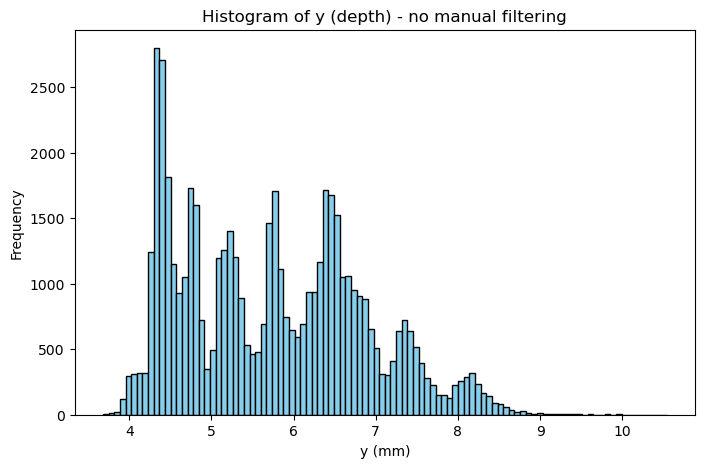

In [45]:
# Histogram of y with unfiltered data (after conversion to NA this excludes bad rows automatically)
plt.figure(figsize=(8,5))
plt.hist(df['y'].dropna(), bins=100, color='skyblue', edgecolor='black')
plt.title('Histogram of y (depth) - no manual filtering')
plt.xlabel('y (mm)')
plt.ylabel('Frequency')
plt.show()

Based on this histogram, does a boxplot look like a good idea? Draw one first, then check if it captures the specifics of your data.

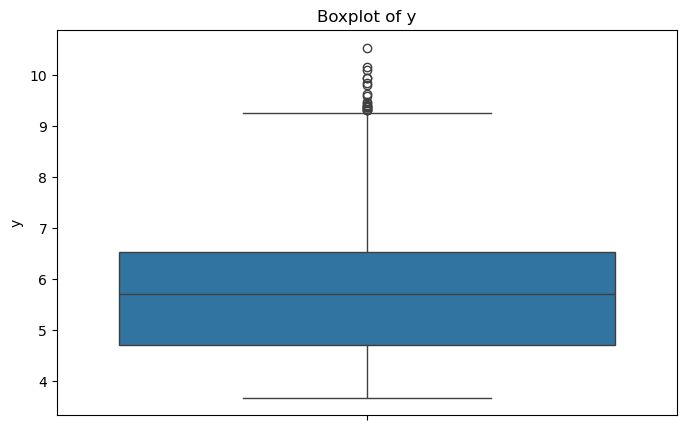

In [46]:
# Boxplot for y
plt.figure(figsize=(8,5))
sns.boxplot(y=df['y'].dropna())
plt.title('Boxplot of y')
plt.show()

No. You miss out on all of the nuances of sizes. Now do multiple boxplots (using seaborn) with all prices per cut.

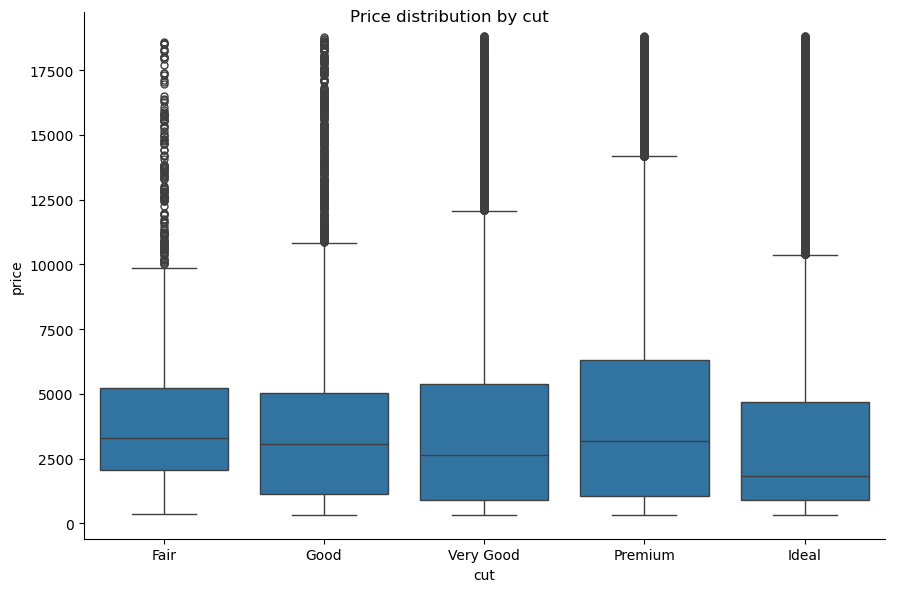

In [47]:
# Multiple boxplots: price by cut
g = sns.catplot(x='cut', y='price', data=df, kind='box', order=cut_order, height=6, aspect=1.5)
g.fig.suptitle('Price distribution by cut')
plt.show()

Looks wrong, doesn't it? You would expect the premium and ideal diamonds to be more expensive.

Although the best cut type is Ideal, its price is the lowest. According to the average prices, the most expensive diamonds belong to Premium and Fair cut types. These results present that cut is not enough to explain response variable price, since price does not increase while cut feature improves.

Do the same, but show the weight in stead of the price.

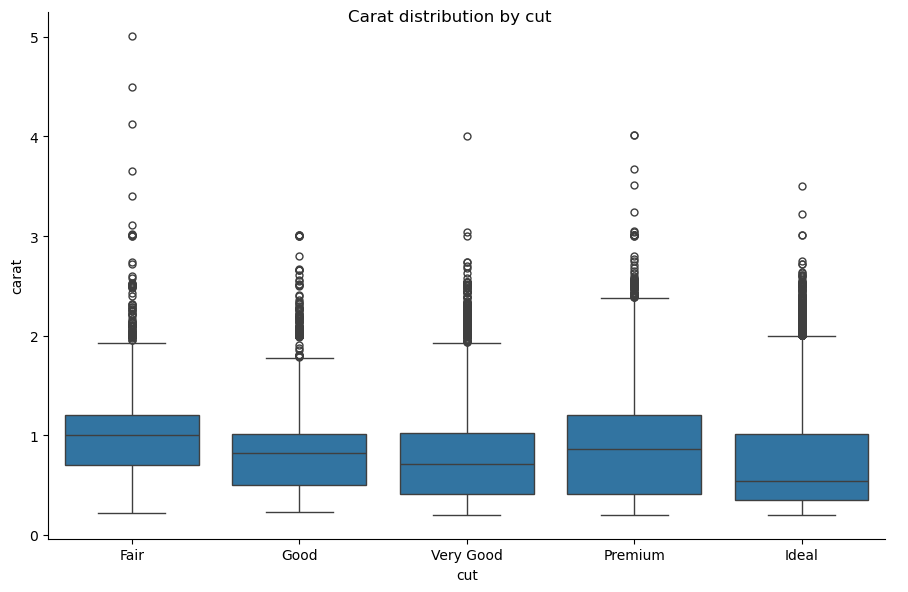

In [48]:
# Boxplot for carat by cut
g = sns.catplot(x='cut', y='carat', data=df, kind='box', order=cut_order, height=6, aspect=1.5)
g.fig.suptitle('Carat distribution by cut')
plt.show()

Still the same picture. Maybe the color comes into play? The color of the diamond goes from D (best) to J (worst) (categoric variable).

In [49]:
# Compare cut with clarity on average price
ct = pd.crosstab(df['cut'], df['clarity'], values=df['price'], aggfunc='mean')
print(ct)

clarity             I1          SI2          SI1          VS2          VS1  \
cut                                                                          
Fair       3703.533333  5173.916309  4208.279412  4174.724138  4165.141176   
Good       3596.635417  4580.260870  3689.533333  4262.236196  3801.445988   
Very Good  4078.226190  4988.688095  3932.391049  4215.759552  3805.353239   
Premium    3947.331707  5545.936928  4455.269371  4550.331248  4485.462041   
Ideal      4335.726027  4755.952656  3752.118169  3284.550385  3489.744497   

clarity           VVS2         VVS1           IF  
cut                                               
Fair       3349.768116  3871.352941  1912.333333  
Good       3079.108392  2254.774194  4098.323944  
Very Good  3037.765182  2459.441065  4396.216418  
Premium    3795.122989  2831.206169  3856.143478  
Ideal      3250.290100  2468.129458  2272.913366  


Although the best color type is D, its price is one of the lowest. According to the average prices, the most expensive diamonds belong to J and I cut types which are actually the worst two color type in this dataset. These results clearly show that color is not enough to explain response variable price, since price does not increase while the color feature improves.

Compare the cut with the clarity on average price. Clarity is a measurement of how clear the diamond is, from I1 (worst), SI2, SI1, VS2, VS1, VVS2, VVS1, IF (best)(categoric variable).

Both are categorical variables by the way, so a [crosstable](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.crosstab.html) would be a good idea.

In [50]:
# Up to you

When cut improves and clarity improves the price isn't higher. So both variables are not enough to explain the price of a diamond.

What would happen if we plot the price vs the carat? Both are continuos variables, so a scatterplot is fine.

You could simply write <code>plt.scatter(df.carat, df.price)</code>, but there would be much room for improvement.

* There are 50.000 dots on there. Make sure they are small enough.
* Add titles on the axes.
* Add a trendline in the first order
* Add a trendline in the fourth order
* Make sure Y is limited between 0 en 20.000 (no values there, but the trendlines want to get out of those limits)

In [51]:
# Up to you


Note the covariance: if price goes up, so goes the weight. Maybe it's the other way around, but you would need a domain-specialist for that (or some common sense). Although covariance or correlation don't always imply causality.

![](files/2022-08-31-15-35-41.png)

[spurious-correlations](http://www.tylervigen.com/spurious-correlations)

Plot a correlation matrix for the numeric values.

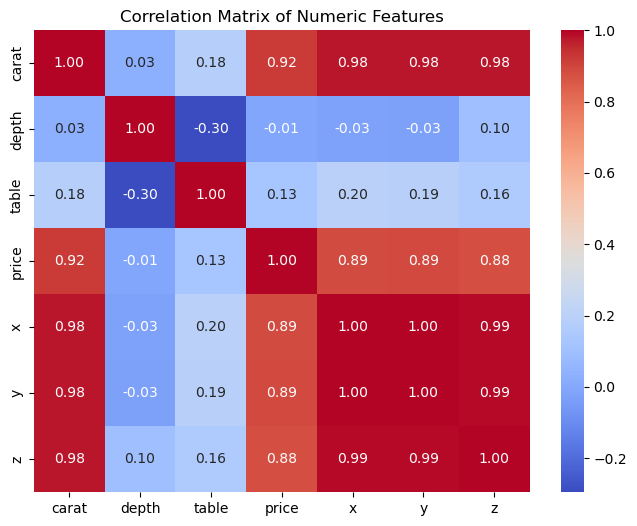

In [52]:
numeric_cols = df.select_dtypes(include=[np.number])
corr_matrix = numeric_cols.corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix of Numeric Features")
plt.show()

Finally, after the EDA formulate at least **3 hypotheses** for further investigation.

1:** The price of a diamond is driven primarily by its physical mass (carat) and physical dimensions (x, y, z), rather than qualitative grading factors like `cut`, `color`, or `clarity`. 
 2:** High qualitative grades (like *Ideal* cut or *D* color) are disproportionately applied to *smaller* diamonds, whereas larger diamonds suffer from inherently worse color/clarity/cuts, which explains why the box plots showed higher median prices for "worse" color and cut graded diamonds (they just happened to be larger diamonds).
 3:** If we control for carat (e.g., standardizing price per metric carat, or looking only at exactly 1.00 carat stones), the expected pricing hierarchy (Ideal > Premium > Good and D > E > F) will re-emerge and correctly correlate positively with stringently cut grades.